# Scenario analysis

This quick analysis evaluates sector-specific deterministic scenarios around the current expected-input base case:

1. electricity: low / medium / high full-load-hour scenarios;
2. electricity: low / medium / high lifetime scenarios;
3. variable renewable electricity: minimum / base / maximum value-factor scenarios;
4. cement: low / medium / high CO2-price scenarios;
5. cement: low / medium / high discount-rate scenarios.

The notebook uses deterministic base inputs from the reusable sensitivity helpers. It does not run Monte Carlo simulations for the scenario cases. Nothing is written to `src/`, `data/`, `results/`, or `figures/`.


In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_summary_figures import CEMENT_TECHNOLOGY_LABELS
from electricity.electricity_npv_summary_figures import ELECTRICITY_TECHNOLOGY_LABELS
from general_parameters import CARBON_PRICE_EUR_PER_T, INTEREST_RATE
from sensitivity_analysis import (
    FINANCIAL_METRIC_OPTIONS,
    base_inputs,
    calculate_metric_value,
)


## Settings

The medium cases are the current deterministic assumptions. Electricity low and high scenarios are editable multipliers around each technology's own deterministic full-load hours and lifetime. Renewable value-factor and cement scenarios use explicit editable absolute values.


In [2]:
CURRENT_CO2_PRICE = CARBON_PRICE_EUR_PER_T.value
CURRENT_DISCOUNT_RATE = INTEREST_RATE.value

ELECTRICITY_FLH_MULTIPLIERS = {
    "Low": 0.80,
    "Medium": 1.00,
    "High": 1.20,
}
ELECTRICITY_LIFETIME_MULTIPLIERS = {
    "Low": 0.80,
    "Medium": 1.00,
    "High": 1.20,
}
ELECTRICITY_VALUE_FACTOR_SCENARIOS = {
    "wind_onshore": {"Min": 0.80, "Base": 0.90, "Max": 1.00},
    "wind_offshore": {"Min": 0.85, "Base": 0.95, "Max": 1.00},
    "pv": {"Min": 0.80, "Base": 0.90, "Max": 1.00},
}
CEMENT_CO2_PRICE_SCENARIOS = {
    "Low": 40.0,
    "Medium": CURRENT_CO2_PRICE,
    "High": 120.0,
}
CEMENT_DISCOUNT_RATE_SCENARIOS = {
    "Low": 0.04,
    "Medium": CURRENT_DISCOUNT_RATE,
    "High": 0.12,
}

# Choose the financial metric used in the scenario figures and summary tables.
FINANCIAL_METRIC = "LNM"  # "NPV", "LNM", or "LCOX"

if FINANCIAL_METRIC not in FINANCIAL_METRIC_OPTIONS:
    raise ValueError(f"Unknown FINANCIAL_METRIC: {FINANCIAL_METRIC!r}")

pd.options.display.float_format = "{:,.3f}".format

scenario_settings = pd.DataFrame(
    [
        {
            "sector": "Electricity",
            "scenario_variable": "Full-load hours",
            "low": "80% of deterministic base",
            "medium": "deterministic base",
            "high": "120% of deterministic base",
        },
        {
            "sector": "Electricity",
            "scenario_variable": "Lifetime",
            "low": "80% of deterministic base",
            "medium": "deterministic base",
            "high": "120% of deterministic base",
        },
        {
            "sector": "Cement",
            "scenario_variable": "CO2 price",
            "low": CEMENT_CO2_PRICE_SCENARIOS["Low"],
            "medium": CEMENT_CO2_PRICE_SCENARIOS["Medium"],
            "high": CEMENT_CO2_PRICE_SCENARIOS["High"],
        },
        {
            "sector": "Cement",
            "scenario_variable": "Discount rate",
            "low": CEMENT_DISCOUNT_RATE_SCENARIOS["Low"],
            "medium": CEMENT_DISCOUNT_RATE_SCENARIOS["Medium"],
            "high": CEMENT_DISCOUNT_RATE_SCENARIOS["High"],
        },
    ]
)
value_factor_settings = (
    pd.DataFrame.from_dict(ELECTRICITY_VALUE_FACTOR_SCENARIOS, orient="index")
    .rename(index=ELECTRICITY_TECHNOLOGY_LABELS)
    .loc[:, ["Min", "Base", "Max"]]
)
value_factor_settings.index.name = "technology"

print(f"Selected financial metric: {FINANCIAL_METRIC}")
display(scenario_settings)
display(value_factor_settings)


Selected financial metric: LNM


,sector,scenario_variable,low,medium,high
0,Electricity,Full-load hours,80% of deterministic base,deterministic base,120% of deterministic base
1,Electricity,Lifetime,80% of deterministic base,deterministic base,120% of deterministic base
2,Cement,CO2 price,40.000,80.000,120.000
3,Cement,Discount rate,0.040,0.080,0.120


,Min,Base,Max
technology,,,
Wind Onshore,0.800,0.900,1.000
Wind Offshore,0.850,0.950,1.000
PV,0.800,0.900,1.000


## Load deterministic base cases

Each scenario starts from the deterministic expected inputs used by the sensitivity dashboard. No sampled Monte Carlo draws are created.


In [3]:
ELECTRICITY_TECHNOLOGIES = tuple(ELECTRICITY_TECHNOLOGY_LABELS)
CEMENT_TECHNOLOGIES = tuple(CEMENT_TECHNOLOGY_LABELS)

electricity_base_inputs = {
    technology: base_inputs("electricity", technology)
    for technology in ELECTRICITY_TECHNOLOGIES
}
cement_base_inputs = {
    technology: base_inputs("cement", technology)
    for technology in CEMENT_TECHNOLOGIES
}

print(f"Electricity deterministic technologies: {len(electricity_base_inputs)}")
print(f"Cement deterministic technologies: {len(cement_base_inputs)}")


Electricity deterministic technologies: 10
Cement deterministic technologies: 9


## Scenario helpers

The helper replaces one deterministic input at a time and recalculates the selected financial metric. Electricity full-load-hour changes also resize capacity through the shared deterministic NPV helper.


In [4]:
SCENARIO_ORDER = ("Low", "Medium", "High")
SCENARIO_COLORS = {"Low": "#6BAED6", "Medium": "#4472C4", "High": "#D95F5F"}
VF_SCENARIO_ORDER = ("Min", "Base", "Max")
VF_SCENARIO_COLORS = {"Min": "#D95F5F", "Base": "#4472C4", "Max": "#6BAED6"}


def metric_label(sector_key):
    if FINANCIAL_METRIC == "NPV":
        return "NPV"
    if FINANCIAL_METRIC == "LNM":
        return "levelized net margin"
    if FINANCIAL_METRIC == "LCOX":
        return "LCOE" if sector_key == "electricity" else "LCOC"
    raise ValueError(f"Unknown FINANCIAL_METRIC: {FINANCIAL_METRIC!r}")


def metric_unit(sector_key):
    if FINANCIAL_METRIC == "NPV":
        return "million EUR"
    return "EUR/MWh" if sector_key == "electricity" else "EUR/t"


def build_deterministic_scenario_summary(
    sector_key,
    base_by_technology,
    labels,
    scenario_variable,
    attribute,
    scenario_values,
    values_are_multipliers=False,
):
    rows = []
    for technology, inputs in base_by_technology.items():
        base_metric = calculate_metric_value(sector_key, inputs, FINANCIAL_METRIC)
        base_value = getattr(inputs, attribute)
        for scenario, scenario_value in scenario_values.items():
            applied_value = (
                base_value * scenario_value
                if values_are_multipliers
                else scenario_value
            )
            scenario_inputs = replace(inputs, **{attribute: applied_value})
            metric_value = calculate_metric_value(sector_key, scenario_inputs, FINANCIAL_METRIC)
            rows.append(
                {
                    "sector": "Electricity" if sector_key == "electricity" else "Cement",
                    "technology": technology,
                    "label": labels.get(technology, technology),
                    "scenario_variable": scenario_variable,
                    "scenario": scenario,
                    "scenario_setting": scenario_value,
                    "base_value": base_value,
                    "applied_value": applied_value,
                    "metric_value": metric_value,
                    "delta_from_base": metric_value - base_metric,
                }
            )
    return pd.DataFrame(rows)


def plot_scenario_variables(
    summary,
    figure_title,
    sector_key,
    scenario_order=SCENARIO_ORDER,
    scenario_colors=SCENARIO_COLORS,
    reference_scenario="Medium",
    figure_height=7.5,
):
    variables = summary["scenario_variable"].drop_duplicates().tolist()
    max_abs_metric_value = float(summary["metric_value"].abs().max())
    x_margin = max(1.0, 0.08 * max_abs_metric_value)
    x_limit = max_abs_metric_value + x_margin
    fig, axes = plt.subplots(
        1,
        len(variables),
        figsize=(8.5 * len(variables), figure_height),
        dpi=150,
    )
    if len(variables) == 1:
        axes = [axes]

    for ax, variable in zip(axes, variables):
        variable_data = summary[summary["scenario_variable"] == variable]
        reference_order = (
            variable_data[variable_data["scenario"] == reference_scenario]
            .sort_values("metric_value", ascending=True)["label"]
            .tolist()
        )
        y = np.arange(len(reference_order))
        bar_height = 0.22
        offsets = (
            np.arange(len(scenario_order)) - (len(scenario_order) - 1) / 2
        ) * bar_height

        for offset, scenario in zip(offsets, scenario_order):
            values = (
                variable_data[variable_data["scenario"] == scenario]
                .set_index("label")
                .loc[reference_order, "metric_value"]
            )
            ax.barh(
                y + offset,
                values,
                height=bar_height * 0.88,
                color=scenario_colors[scenario],
                label=scenario,
            )

        ax.set_yticks(y)
        ax.set_yticklabels(reference_order, fontsize=9)
        ax.tick_params(axis="y", left=False, length=0)
        ax.axvline(0, color="#777777", linewidth=0.9)
        ax.grid(axis="x", color="#e6e6e6", linewidth=0.8)
        ax.set_axisbelow(True)
        ax.set_title(variable, fontsize=13)
        ax.set_xlabel(f"Deterministic {metric_label(sector_key)} ({metric_unit(sector_key)})")
        ax.set_xlim(-x_limit, x_limit)
        for spine in ax.spines.values():
            spine.set_visible(False)

    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        legend_labels,
        title="Scenario",
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.96),
        ncol=len(scenario_order),
    )
    fig.suptitle(figure_title, fontsize=15, y=1.01)
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.90))
    return fig


## Electricity scenarios: full-load hours and lifetime

Full-load hours and lifetime vary around each technology's own deterministic base value. All other electricity inputs remain fixed at their deterministic base values.


,sector,technology,label,scenario_variable,scenario,scenario_setting,base_value,applied_value,metric_value,delta_from_base
0,Electricity,hard_coal,Hard coal,Full-load hours,Low,0.800,"4,100.000","3,280.000",-77.865,-13.164
1,Electricity,hard_coal,Hard coal,Full-load hours,Medium,1.000,"4,100.000","4,100.000",-64.701,0.000
2,Electricity,hard_coal,Hard coal,Full-load hours,High,1.200,"4,100.000","4,920.000",-55.925,8.776
3,Electricity,hard_coal_ccs,Hard coal + CCS,Full-load hours,Low,0.800,"4,100.000","3,280.000",-112.990,-29.999
4,Electricity,hard_coal_ccs,Hard coal + CCS,Full-load hours,Medium,1.000,"4,100.000","4,100.000",-82.990,0.000
5,Electricity,hard_coal_ccs,Hard coal + CCS,Full-load hours,High,1.200,"4,100.000","4,920.000",-62.991,20.000
6,Electricity,ccgt,CCGT,Full-load hours,Low,0.800,"4,650.000","3,720.000",-35.247,-6.364
7,Electricity,ccgt,CCGT,Full-load hours,Medium,1.000,"4,650.000","4,650.000",-28.883,0.000
8,Electricity,ccgt,CCGT,Full-load hours,High,1.200,"4,650.000","5,580.000",-24.640,4.243
9,Electricity,ccgt_ccs,CCGT + CCS,Full-load hours,Low,0.800,"4,650.000","3,720.000",-56.637,-13.144


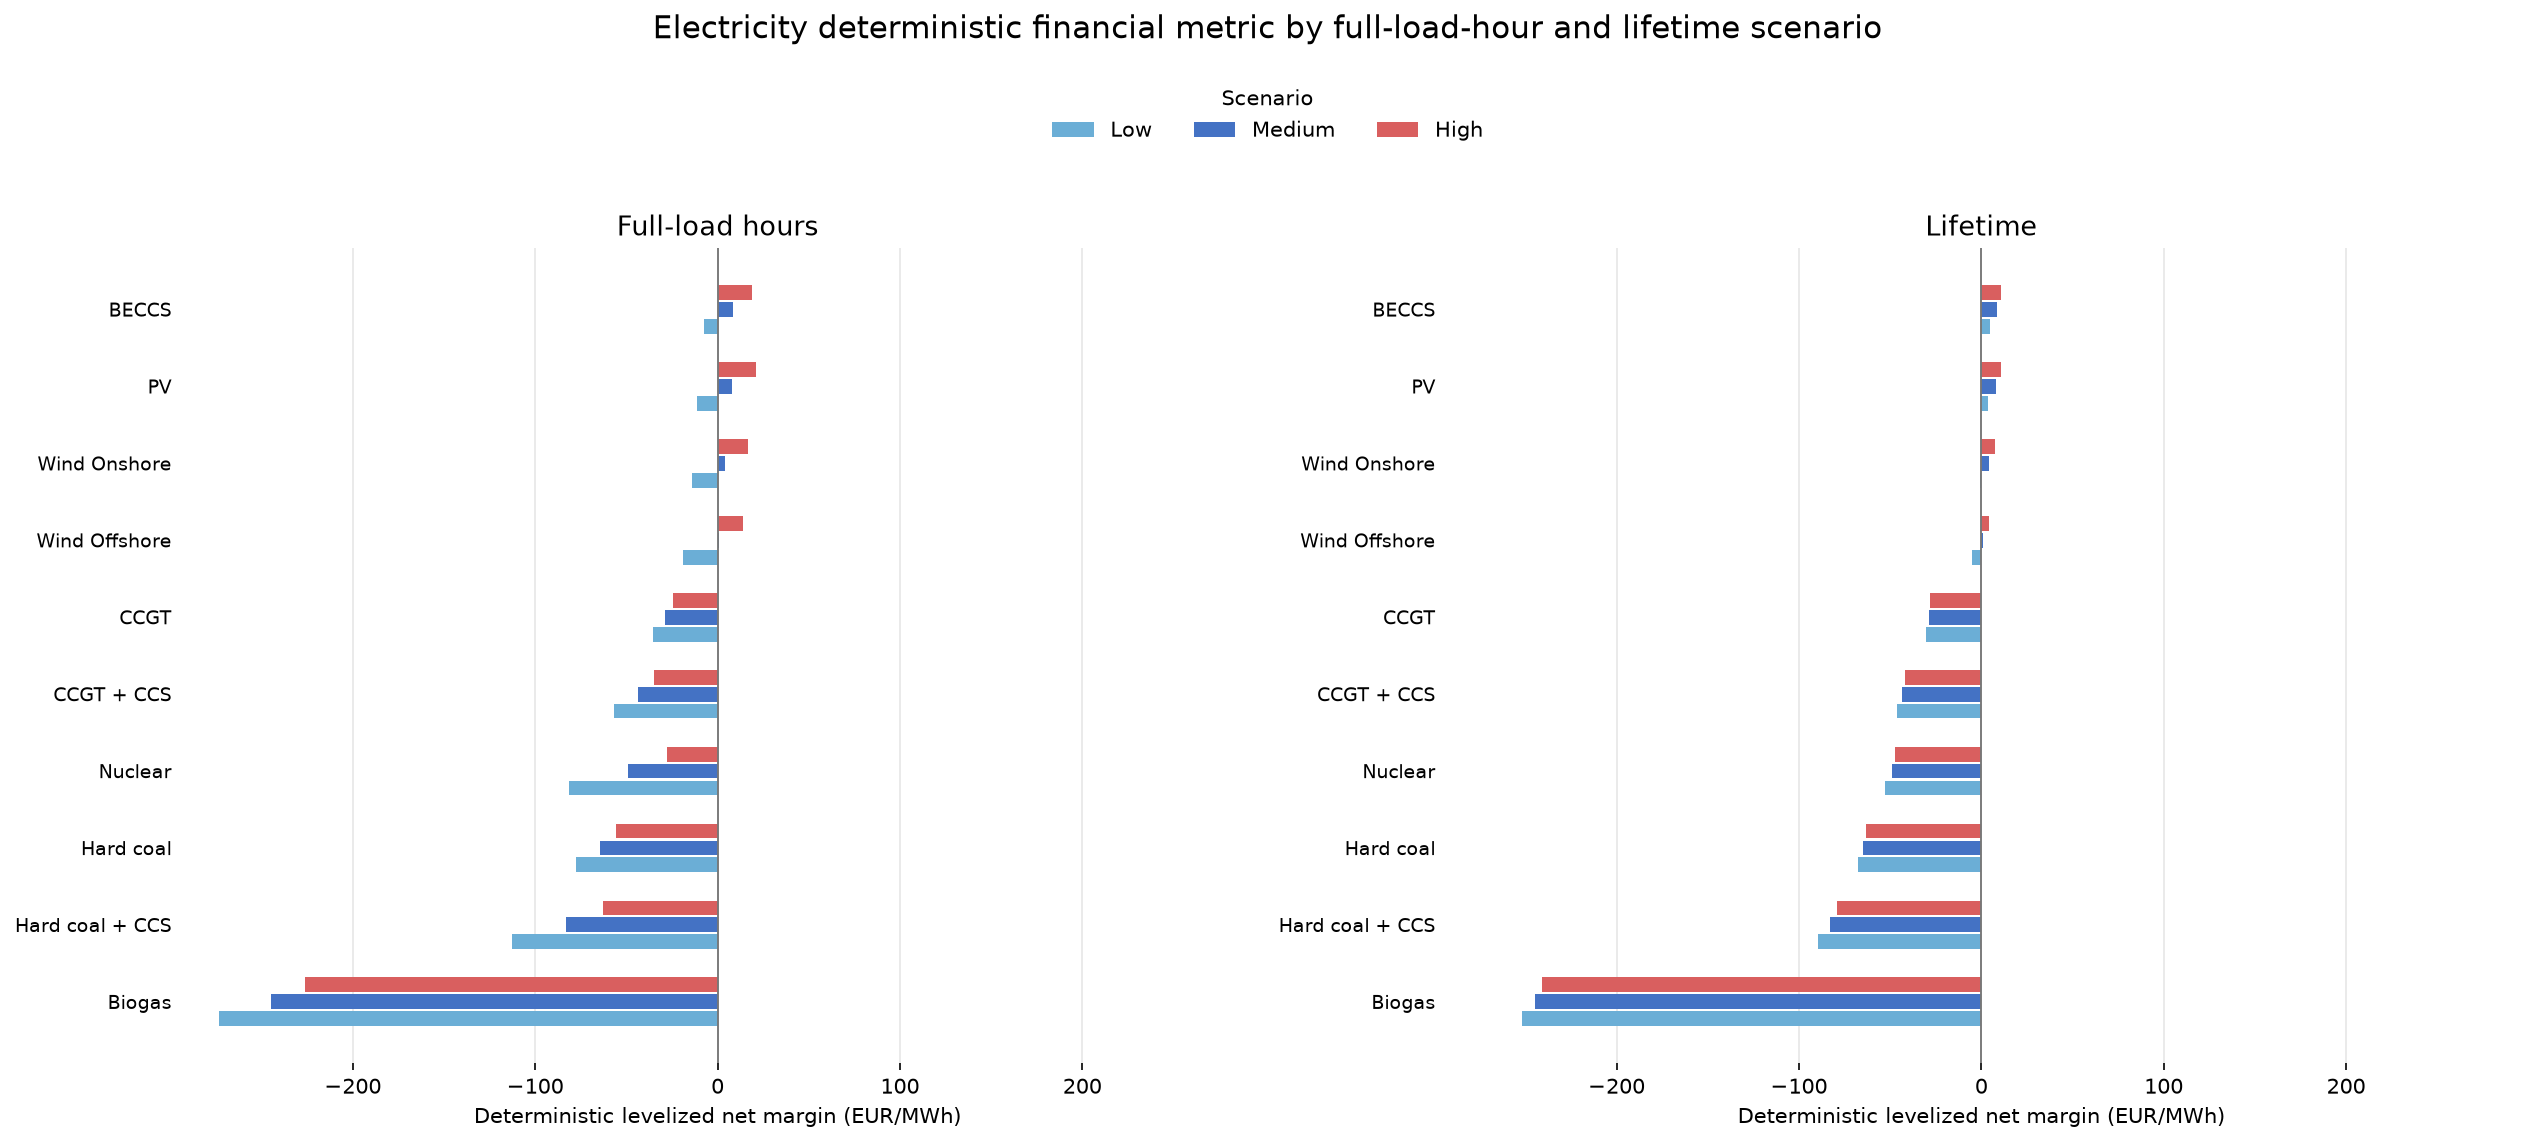

In [5]:
electricity_summary = pd.concat(
    [
        build_deterministic_scenario_summary(
            "electricity",
            electricity_base_inputs,
            ELECTRICITY_TECHNOLOGY_LABELS,
            "Full-load hours",
            "full_load_hours",
            ELECTRICITY_FLH_MULTIPLIERS,
            values_are_multipliers=True,
        ),
        build_deterministic_scenario_summary(
            "electricity",
            electricity_base_inputs,
            ELECTRICITY_TECHNOLOGY_LABELS,
            "Lifetime",
            "lifetime_years",
            ELECTRICITY_LIFETIME_MULTIPLIERS,
            values_are_multipliers=True,
        ),
    ],
    ignore_index=True,
)

display(electricity_summary)
plot_scenario_variables(
    electricity_summary,
    "Electricity deterministic financial metric by full-load-hour and lifetime scenario",
    "electricity",
)
plt.show()


## Renewable electricity value-factor scenarios

The value factor scales the existing electricity sales-price proxy for onshore wind, offshore wind, and solar PV. The minimum, base, and maximum values match the triangular Monte Carlo assumptions; deterministic results use the base value. Value factors affect revenue, NPV, and LNM; they do not affect the cost-only LCOE (`LCOX`).


,sector,technology,label,scenario_variable,scenario,scenario_setting,base_value,applied_value,metric_value,delta_from_base
0,Electricity,wind_onshore,Wind Onshore,Value factor,Min,0.800,0.900,0.800,-5.158,-9.407
1,Electricity,wind_onshore,Wind Onshore,Value factor,Base,0.900,0.900,0.900,4.249,0.000
2,Electricity,wind_onshore,Wind Onshore,Value factor,Max,1.000,0.900,1.000,13.656,9.407
3,Electricity,wind_offshore,Wind Offshore,Value factor,Min,0.850,0.933,0.850,-6.905,-7.839
4,Electricity,wind_offshore,Wind Offshore,Value factor,Base,0.950,0.933,0.950,2.502,1.568
5,Electricity,wind_offshore,Wind Offshore,Value factor,Max,1.000,0.933,1.000,7.206,6.271
6,Electricity,pv,PV,Value factor,Min,0.800,0.900,0.800,-1.309,-9.407
7,Electricity,pv,PV,Value factor,Base,0.900,0.900,0.900,8.098,0.000
8,Electricity,pv,PV,Value factor,Max,1.000,0.900,1.000,17.505,9.407


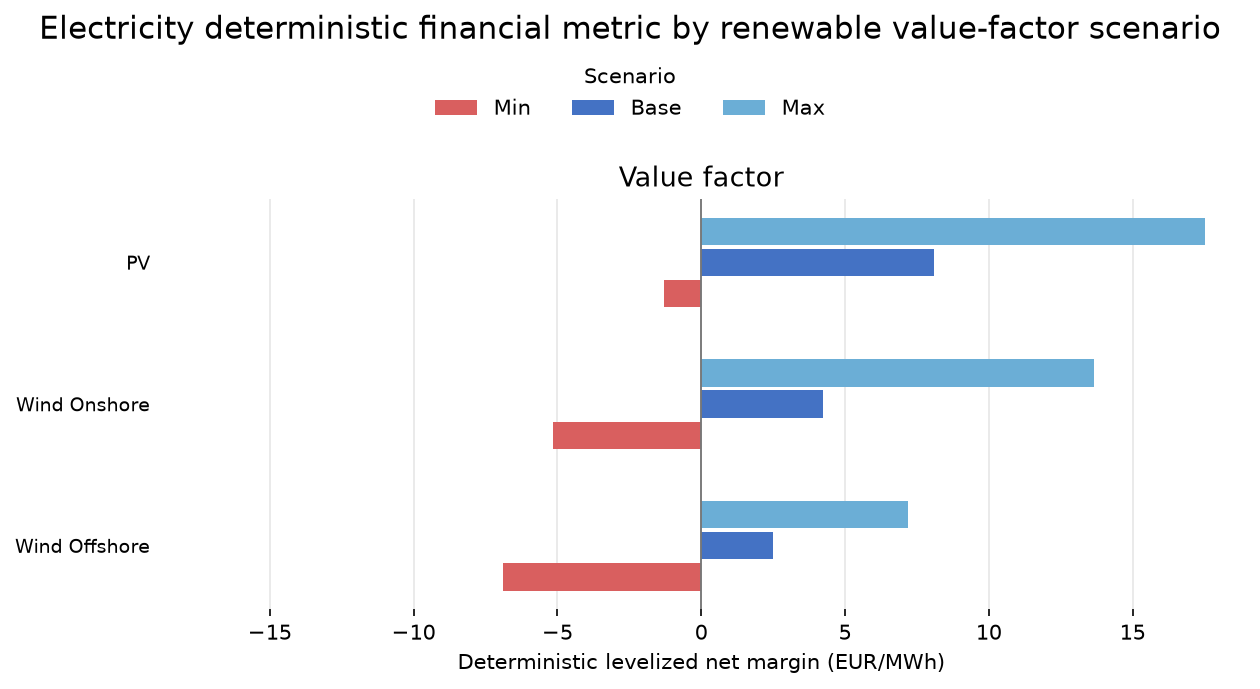

In [6]:
electricity_value_factor_summary = pd.concat(
    [
        build_deterministic_scenario_summary(
            "electricity",
            {technology: electricity_base_inputs[technology]},
            ELECTRICITY_TECHNOLOGY_LABELS,
            "Value factor",
            "value_factor",
            scenarios,
        )
        for technology, scenarios in ELECTRICITY_VALUE_FACTOR_SCENARIOS.items()
    ],
    ignore_index=True,
)

value_factor_metrics = electricity_value_factor_summary.pivot(
    index="technology",
    columns="scenario",
    values="metric_value",
)
if FINANCIAL_METRIC in {"NPV", "LNM"}:
    assert (value_factor_metrics["Max"] > value_factor_metrics["Base"]).all()
    assert (value_factor_metrics["Base"] > value_factor_metrics["Min"]).all()
else:
    np.testing.assert_allclose(
        value_factor_metrics.loc[:, VF_SCENARIO_ORDER],
        np.repeat(
            value_factor_metrics[["Base"]].to_numpy(),
            len(VF_SCENARIO_ORDER),
            axis=1,
        ),
    )

display(electricity_value_factor_summary)
plot_scenario_variables(
    electricity_value_factor_summary,
    "Electricity deterministic financial metric by renewable value-factor scenario",
    "electricity",
    scenario_order=VF_SCENARIO_ORDER,
    scenario_colors=VF_SCENARIO_COLORS,
    reference_scenario="Base",
    figure_height=4.5,
)
plt.show()


## Cement scenarios: CO2 price and discount rate

CO2 price and discount rate use explicit low / medium / high values. All other cement inputs remain fixed at their deterministic base values.


,sector,technology,label,scenario_variable,scenario,scenario_setting,base_value,applied_value,metric_value,delta_from_base
0,Cement,bau,BAU,CO2 price,Low,40.000,80.000,40.000,71.999,25.333
1,Cement,bau,BAU,CO2 price,Medium,80.000,80.000,80.000,46.666,0.000
2,Cement,bau,BAU,CO2 price,High,120.000,80.000,120.000,21.333,-25.333
3,Cement,electrification,Electrification,CO2 price,Low,40.000,80.000,40.000,-24.680,16.000
4,Cement,electrification,Electrification,CO2 price,Medium,80.000,80.000,80.000,-40.680,0.000
5,Cement,electrification,Electrification,CO2 price,High,120.000,80.000,120.000,-56.680,-16.000
6,Cement,electrolysis,Electrolysis,CO2 price,Low,40.000,80.000,40.000,-220.628,4.000
7,Cement,electrolysis,Electrolysis,CO2 price,Medium,80.000,80.000,80.000,-224.628,0.000
8,Cement,electrolysis,Electrolysis,CO2 price,High,120.000,80.000,120.000,-228.628,-4.000
9,Cement,clinker_substitution,Clinker substitution,CO2 price,Low,40.000,80.000,40.000,72.001,22.167


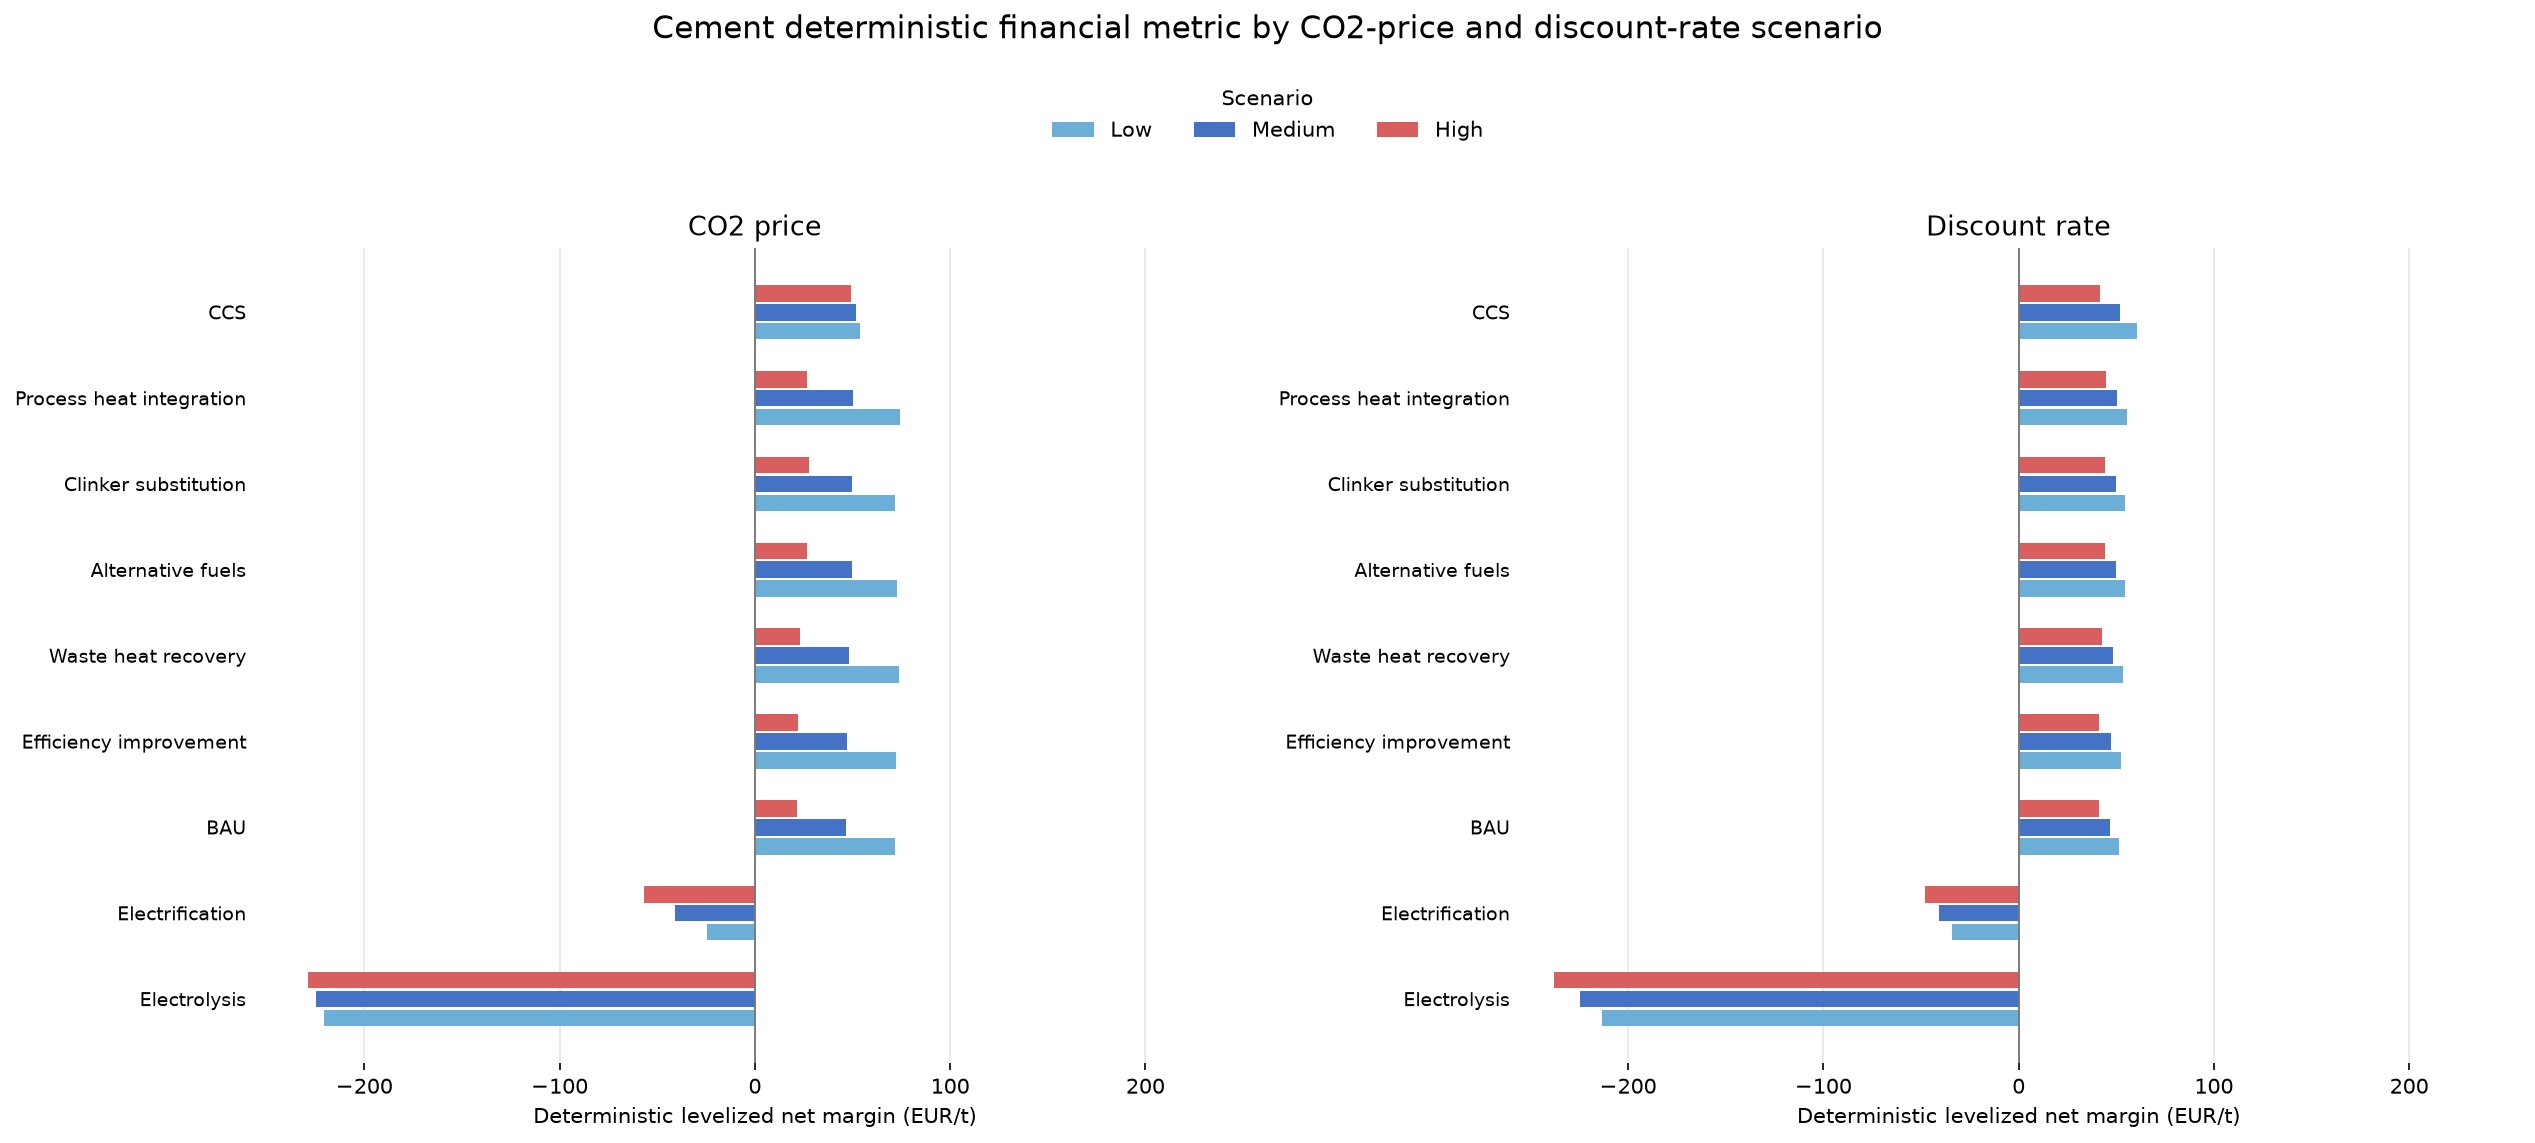

In [7]:
cement_summary = pd.concat(
    [
        build_deterministic_scenario_summary(
            "cement",
            cement_base_inputs,
            CEMENT_TECHNOLOGY_LABELS,
            "CO2 price",
            "carbon_price",
            CEMENT_CO2_PRICE_SCENARIOS,
        ),
        build_deterministic_scenario_summary(
            "cement",
            cement_base_inputs,
            CEMENT_TECHNOLOGY_LABELS,
            "Discount rate",
            "discount_rate",
            CEMENT_DISCOUNT_RATE_SCENARIOS,
        ),
    ],
    ignore_index=True,
)

display(cement_summary)
plot_scenario_variables(
    cement_summary,
    "Cement deterministic financial metric by CO2-price and discount-rate scenario",
    "cement",
)
plt.show()


## Interpretation guardrails

- The renewable minimum/base/maximum scenarios match the triangular value-factor parameters in `src/`.
- The medium cases come from the deterministic base assumptions in `src/`.
- The renewable Base values are the deterministic triangular means: 0.90 for onshore wind and PV, and 0.933 for offshore wind.
- Monte Carlo electricity simulations sample the full value-factor ranges.
- Value factors scale captured electricity price and sales revenue only; generation, capacity, costs, and LCOE remain unchanged.
- Scenario comparisons are deterministic: no Monte Carlo simulations or sampled scenario cases are used.
- Electricity FLH and lifetime scenarios use relative multipliers because the deterministic base values differ by technology.
- Cement CO2-price and discount-rate scenarios use absolute editable values.
